<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/03_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - connect my Drive and install rasterio (Colab doesn't have it by default)
from google.colab import drive
drive.mount('/content/drive')
!pip install -q rasterio

Mounted at /content/drive


In [2]:
# Cell 2 - read the 6 feature values under each training point
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

base = "/content/drive/MyDrive/landslide_project"
band_names = ["elevation", "slope", "aspect", "ndvi", "landcover", "dist_river"]

points = gpd.read_file(f"{base}/training_points.geojson")

with rasterio.open(f"{base}/rudraprayag_features.tif") as src:
    # making sure the points are in the same projection as the raster before sampling
    points = points.to_crs(src.crs)
    coords = [(p.x, p.y) for p in points.geometry]
    values = np.array(list(src.sample(coords)))

df = pd.DataFrame(values, columns=band_names)
df["label"] = points["label"].values
df["x"] = [p.x for p in points.geometry]
df["y"] = [p.y for p in points.geometry]

print("points:", len(df))
print(df["label"].value_counts())
print("points with elevation 0 (outside district, shouldn't happen):", (df["elevation"] == 0).sum())
print()
print("average feature values by label (1 = landslide, 0 = no landslide):")
print(df.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))
print()
print("land cover classes by label:")
print(pd.crosstab(df["landcover"], df["label"]))

points: 76
label
1    38
0    38
Name: count, dtype: int64
points with elevation 0 (outside district, shouldn't happen): 0

average feature values by label (1 = landslide, 0 = no landslide):
         elevation  slope  ndvi   dist_river
label                                       
0      2044.290039  33.41  0.62  1079.760010
1      2506.419922  37.23  0.16   316.730011

land cover classes by label:
label       0   1
landcover        
10.0       27   7
30.0       10   9
50.0        1   0
60.0        0  21
100.0       0   1


terrain features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'dist_river']
full features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'dist_river', 'ndvi', 'lc_bare', 'lc_grass', 'lc_other', 'lc_tree']

points per block and label:
label   0   1
block        
0       5  15
1      11   2
2      11   6
3       8   1
4       3  14


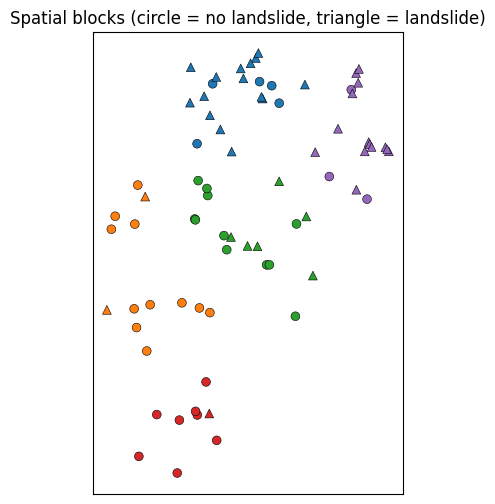

In [3]:
# Cell 3 - prepare features and split the district into spatial blocks
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# aspect is circular (359° and 1° are both north), so I'm turning it into sin/cos
df["aspect_sin"] = np.sin(np.deg2rad(df["aspect"]))
df["aspect_cos"] = np.cos(np.deg2rad(df["aspect"]))

# land cover is categorical, so I'm grouping it into a few classes and one-hot encoding it
# (only for the comparison model - bare land cover mostly IS the landslide scar)
lc_group = df["landcover"].map({10: "tree", 30: "grass", 60: "bare"}).fillna("other")
df = pd.concat([df, pd.get_dummies(lc_group, prefix="lc").astype(int)], axis=1)

terrain_features = ["elevation", "slope", "aspect_sin", "aspect_cos", "dist_river"]
full_features = terrain_features + ["ndvi"] + [c for c in df.columns if c.startswith("lc_")]

# spatial blocks: k-means on the point coordinates gives 5 geographic groups
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["block"] = kmeans.fit_predict(df[["x", "y"]])

print("terrain features:", terrain_features)
print("full features:", full_features)
print()
print("points per block and label:")
print(pd.crosstab(df["block"], df["label"]))

# quick map so I can see the blocks
fig, ax = plt.subplots(figsize=(5, 6))
for lab, marker in [(0, "o"), (1, "^")]:
    sub = df[df["label"] == lab]
    ax.scatter(sub["x"], sub["y"], c=sub["block"], cmap="tab10", vmin=0, vmax=9,
               marker=marker, s=40, edgecolor="k", linewidth=0.4)
ax.set_title("Spatial blocks (circle = no landslide, triangle = landslide)")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [4]:
# Cell 4 - random forest with random CV vs spatial CV, three feature sets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

labels = df["label"].values
feature_sets = {
    "terrain": terrain_features,
    "full (circular)": full_features,
    "coordinates only": ["x", "y"],
}

def make_rf(seed):
    # small dataset, so I'm keeping leaves from getting too tiny (min 2 points)
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  random_state=seed, n_jobs=-1)

def random_cv_auc(features, seed):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    prob = cross_val_predict(make_rf(seed), df[features], labels, cv=cv,
                             method="predict_proba")[:, 1]
    return roc_auc_score(labels, prob)

def spatial_cv_auc(features, seed):
    # new block layout each repeat, then hold out one block at a time
    blocks = KMeans(n_clusters=5, random_state=seed, n_init=10).fit_predict(df[["x", "y"]])
    prob = cross_val_predict(make_rf(seed), df[features], labels, groups=blocks,
                             cv=LeaveOneGroupOut(), method="predict_proba")[:, 1]
    # pooling predictions from all held-out blocks, since some blocks have only one label
    return roc_auc_score(labels, prob)

rows = []
for name, feats in feature_sets.items():
    for seed in range(10):
        rows.append({"model": name, "cv": "random", "seed": seed, "auc": random_cv_auc(feats, seed)})
        rows.append({"model": name, "cv": "spatial", "seed": seed, "auc": spatial_cv_auc(feats, seed)})

results = pd.DataFrame(rows)
summary = results.groupby(["model", "cv"])["auc"].agg(["mean", "std"]).round(3)
print(summary)

                           mean    std
model            cv                   
coordinates only random   0.791  0.022
                 spatial  0.829  0.007
full (circular)  random   0.946  0.005
                 spatial  0.947  0.004
terrain          random   0.841  0.017
                 spatial  0.852  0.004


In [5]:
# Cell 5 - which terrain feature carries the signal? (spatial CV, 10 repeats each)
feature_groups = {
    "elevation": ["elevation"],
    "slope": ["slope"],
    "aspect": ["aspect_sin", "aspect_cos"],   # sin and cos belong together
    "dist_river": ["dist_river"],
}

rows = []
for name, feats in feature_groups.items():
    rest = [f for f in terrain_features if f not in feats]
    for seed in range(10):
        rows.append({"test": f"only {name}", "auc": spatial_cv_auc(feats, seed)})
        rows.append({"test": f"without {name}", "auc": spatial_cv_auc(rest, seed)})

diag = pd.DataFrame(rows).groupby("test")["auc"].agg(["mean", "std"]).round(3)
print(diag)
print()
print("reference - all terrain features:", summary.loc[("terrain", "spatial"), "mean"])
print("reference - coordinates only:   ", summary.loc[("coordinates only", "spatial"), "mean"])
print()
# how much is each feature just "where you are"? (y = northing, x = easting)
for f in ["elevation", "slope", "dist_river"]:
    print(f"correlation of {f} with northing: {np.corrcoef(df[f], df['y'])[0, 1]:.2f}")

                     mean    std
test                            
only aspect         0.458  0.006
only dist_river     0.792  0.005
only elevation      0.497  0.006
only slope          0.368  0.005
without aspect      0.896  0.005
without dist_river  0.591  0.012
without elevation   0.784  0.006
without slope       0.833  0.004

reference - all terrain features: 0.852
reference - coordinates only:    0.829

correlation of elevation with northing: 0.71
correlation of slope with northing: 0.12
correlation of dist_river with northing: -0.48


search radius used per landslide: {3000: 38}
label
1    38
0    38
Name: count, dtype: int64

averages by label (matched set):
         elevation      slope  ndvi  dist_river
label                                          
0      2648.919922  34.610001  0.59  686.780029
1      2506.419922  37.230000  0.16  316.730011


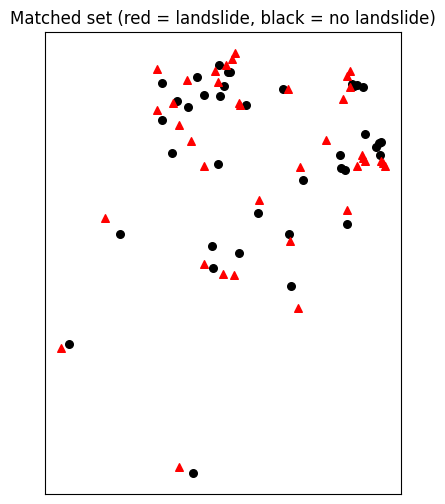

In [6]:
# Cell 6 - new no-landslide points drawn NEAR the landslides (same valleys),
# so the model can't win just by knowing north from south
tif = f"{base}/rudraprayag_features.tif"
rng = np.random.default_rng(42)

with rasterio.open(tif) as src:
    elev_full = src.read(1)
    lc_full = src.read(5)
    tr = src.transform

# same allowed terrain as before: inside district, below 3500 m, not snow/ice or water
valid = (elev_full > 0) & (elev_full < 3500) & (lc_full != 70) & (lc_full != 80)
vr, vc = np.where(valid)
take = rng.choice(len(vr), size=min(200_000, len(vr)), replace=False)
px, py = rasterio.transform.xy(tr, vr[take], vc[take])
px, py = np.array(px), np.array(py)

ls_xy = df.loc[df["label"] == 1, ["x", "y"]].values

# every candidate must stay more than 500 m from ANY landslide (same rule as before)
d_any = np.full(len(px), np.inf)
for lx, ly in ls_xy:
    d_any = np.minimum(d_any, np.hypot(px - lx, py - ly))
ok = d_any > 500

# for each landslide, pick one stable point within 3 km (widen to 5 or 10 km if nothing fits)
used = np.zeros(len(px), dtype=bool)
chosen, radius_used = [], []
for lx, ly in ls_xy:
    d = np.hypot(px - lx, py - ly)
    for radius in [3000, 5000, 10000]:
        cand = np.where(ok & ~used & (d <= radius))[0]
        if len(cand) > 0:
            break
    j = rng.choice(cand)
    used[j] = True
    chosen.append(j)
    radius_used.append(radius)

print("search radius used per landslide:", pd.Series(radius_used).value_counts().to_dict())

# read the 6 features at the new stable points
new_xy = list(zip(px[chosen], py[chosen]))
with rasterio.open(tif) as src:
    new_vals = np.array(list(src.sample(new_xy)))

stable_m = pd.DataFrame(new_vals, columns=band_names)
stable_m["label"] = 0
stable_m["x"] = px[chosen]
stable_m["y"] = py[chosen]

df_m = pd.concat([df.loc[df["label"] == 1, band_names + ["label", "x", "y"]], stable_m],
                 ignore_index=True)
df_m["aspect_sin"] = np.sin(np.deg2rad(df_m["aspect"]))
df_m["aspect_cos"] = np.cos(np.deg2rad(df_m["aspect"]))

# saving the matched set separately - the original training_points.geojson stays untouched
gpd.GeoDataFrame(df_m[["label"]], geometry=gpd.points_from_xy(df_m["x"], df_m["y"]),
                 crs="EPSG:32644").to_file(f"{base}/training_points_matched.geojson", driver="GeoJSON")

print(df_m["label"].value_counts())
print()
print("averages by label (matched set):")
print(df_m.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))

fig, ax = plt.subplots(figsize=(5, 6))
for lab, marker, colour in [(0, "o", "black"), (1, "^", "red")]:
    sub = df_m[df_m["label"] == lab]
    ax.scatter(sub["x"], sub["y"], marker=marker, c=colour, s=30)
ax.set_title("Matched set (red = landslide, black = no landslide)")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [7]:
# Cell 7 - same three models, now on the matched points
# land cover columns for the comparison model (same grouping as before)
lc_m = df_m["landcover"].map({10: "tree", 30: "grass", 60: "bare"}).fillna("other")
lc_cols = [c for c in full_features if c.startswith("lc_")]
df_m = pd.concat([df_m, pd.get_dummies(lc_m, prefix="lc").astype(int)
                  .reindex(columns=lc_cols, fill_value=0)], axis=1)

def evaluate(data, features, seed, mode):
    lab = data["label"].values
    if mode == "random":
        groups = None
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    else:
        groups = KMeans(n_clusters=5, random_state=seed, n_init=10).fit_predict(data[["x", "y"]])
        cv = LeaveOneGroupOut()
    prob = cross_val_predict(make_rf(seed), data[features], lab, cv=cv, groups=groups,
                             method="predict_proba")[:, 1]
    pooled = roc_auc_score(lab, prob)
    within = np.nan
    if mode == "spatial":
        # AUC inside each held-out block - only blocks that contain both labels count
        per_block = [roc_auc_score(lab[groups == g], prob[groups == g])
                     for g in np.unique(groups) if len(np.unique(lab[groups == g])) == 2]
        within = np.mean(per_block)
    return pooled, within

rows = []
for name, feats in feature_sets.items():
    for seed in range(10):
        for mode in ["random", "spatial"]:
            pooled, within = evaluate(df_m, feats, seed, mode)
            rows.append({"model": name, "cv": mode, "seed": seed,
                         "pooled_auc": pooled, "within_block_auc": within})

results_m = pd.DataFrame(rows)
summary_m = results_m.groupby(["model", "cv"])[["pooled_auc", "within_block_auc"]].agg(["mean", "std"]).round(3)
print(summary_m)

                         pooled_auc        within_block_auc       
                               mean    std             mean    std
model            cv                                               
coordinates only random       0.400  0.040              NaN    NaN
                 spatial      0.485  0.028            0.386  0.026
full (circular)  random       0.942  0.007              NaN    NaN
                 spatial      0.928  0.005            0.935  0.004
terrain          random       0.669  0.033              NaN    NaN
                 spatial      0.623  0.023            0.721  0.048


In [8]:
# Cell 8 - which terrain features matter once location is removed? (within-block AUC)
print("search radius used per landslide:", pd.Series(radius_used).value_counts().to_dict())
print()
print("averages by label (matched set):")
print(df_m.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))
print()

rows = []
for name, feats in feature_groups.items():
    rest = [f for f in terrain_features if f not in feats]
    for seed in range(10):
        _, only_auc = evaluate(df_m, feats, seed, "spatial")
        _, without_auc = evaluate(df_m, rest, seed, "spatial")
        rows.append({"test": f"only {name}", "auc": only_auc})
        rows.append({"test": f"without {name}", "auc": without_auc})

diag_m = pd.DataFrame(rows).groupby("test")["auc"].agg(["mean", "std"]).round(3)
print(diag_m)
print()
print("reference - all terrain features (within-block):",
      summary_m.loc[("terrain", "spatial"), ("within_block_auc", "mean")])

search radius used per landslide: {3000: 38}

averages by label (matched set):
         elevation      slope  ndvi  dist_river
label                                          
0      2648.919922  34.610001  0.59  686.780029
1      2506.419922  37.230000  0.16  316.730011

                     mean    std
test                            
only aspect         0.422  0.006
only dist_river     0.669  0.041
only elevation      0.563  0.021
only slope          0.660  0.065
without aspect      0.737  0.050
without dist_river  0.716  0.016
without elevation   0.520  0.104
without slope       0.704  0.044

reference - all terrain features (within-block): 0.721


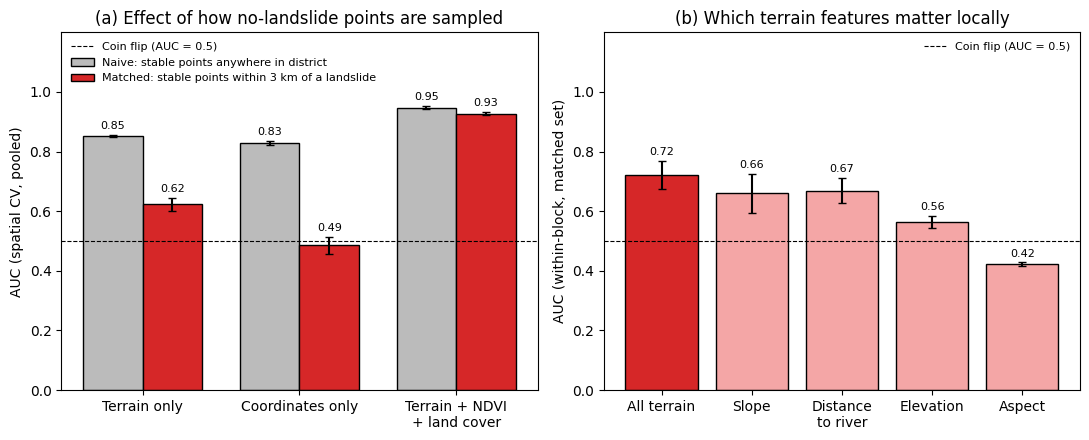

In [11]:
# Cell 9 - Figure 4: model evaluation (naive vs matched sampling + which features matter)
models = ["terrain", "coordinates only", "full (circular)"]
model_labels = ["Terrain only", "Coordinates only", "Terrain + NDVI\n+ land cover"]

# panel (a): pooled spatial-CV AUC for both sampling designs, so the metric is the same
naive = results[results["cv"] == "spatial"].groupby("model")["auc"].agg(["mean", "std"]).loc[models]
matched = results_m[results_m["cv"] == "spatial"].groupby("model")["pooled_auc"].agg(["mean", "std"]).loc[models]

# panel (b): within-block AUC on the matched set, all terrain + each feature alone
b_tests = ["only slope", "only dist_river", "only elevation", "only aspect"]
b_means = [summary_m.loc[("terrain", "spatial"), ("within_block_auc", "mean")]] + [diag_m.loc[t, "mean"] for t in b_tests]
b_stds = [summary_m.loc[("terrain", "spatial"), ("within_block_auc", "std")]] + [diag_m.loc[t, "std"] for t in b_tests]
b_labels = ["All terrain", "Slope", "Distance\nto river", "Elevation", "Aspect"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.arange(len(models))
w = 0.38
ax1.bar(x - w/2, naive["mean"], w, yerr=naive["std"], capsize=3, color="#bbbbbb",
        edgecolor="black", label="Naive: stable points anywhere in district")
ax1.bar(x + w/2, matched["mean"], w, yerr=matched["std"], capsize=3, color="#d62728",
        edgecolor="black", label="Matched: stable points within 3 km of a landslide")
# labels go above the error bar, not just above the bar (0.49 was sitting on its error bar)
for xi, m, s in zip(x - w/2, naive["mean"], naive["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
for xi, m, s in zip(x + w/2, matched["mean"], matched["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
ax1.axhline(0.5, ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.2)
ax1.set_ylabel("AUC (spatial CV, pooled)")
ax1.set_title("(a) Effect of how no-landslide points are sampled")
ax1.legend(loc="upper left", fontsize=8, frameon=False)

# the first bar (all terrain) is the headline, so I'm making it stand out
colours = ["#d62728"] + ["#f4a6a6"] * 4
ax2.bar(np.arange(5), b_means, yerr=b_stds, capsize=3, color=colours, edgecolor="black")
for i, (m, s) in enumerate(zip(b_means, b_stds)):
    ax2.text(i, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
ax2.axhline(0.5, ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")
ax2.legend(loc="upper right", fontsize=8, frameon=False)
ax2.set_xticks(np.arange(5))
ax2.set_xticklabels(b_labels)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel("AUC (within-block, matched set)")
ax2.set_title("(b) Which terrain features matter locally")
# AUC can't go above 1, so I only want ticks up to 1.0 (the extra space is for labels)
for ax in (ax1, ax2):
    ax.set_yticks(np.arange(0, 1.01, 0.2))
plt.tight_layout()
plt.savefig(f"{base}/figures/fig4_model_evaluation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig4_model_evaluation.pdf", bbox_inches="tight")
plt.show()

In [12]:
# Cell 10 - lat/lon copy of the matched points for GitHub (the Drive copy stays in UTM)
m = gpd.read_file(f"{base}/training_points_matched.geojson")
m.to_crs("EPSG:4326").to_file(f"{base}/training_points_matched_wgs84.geojson", driver="GeoJSON")
print(len(m), "points saved")

76 points saved
